<a href="https://colab.research.google.com/github/fauziah-azzhr/PertemuanKesepuluh/blob/main/Pertemuan10LatihanPraktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

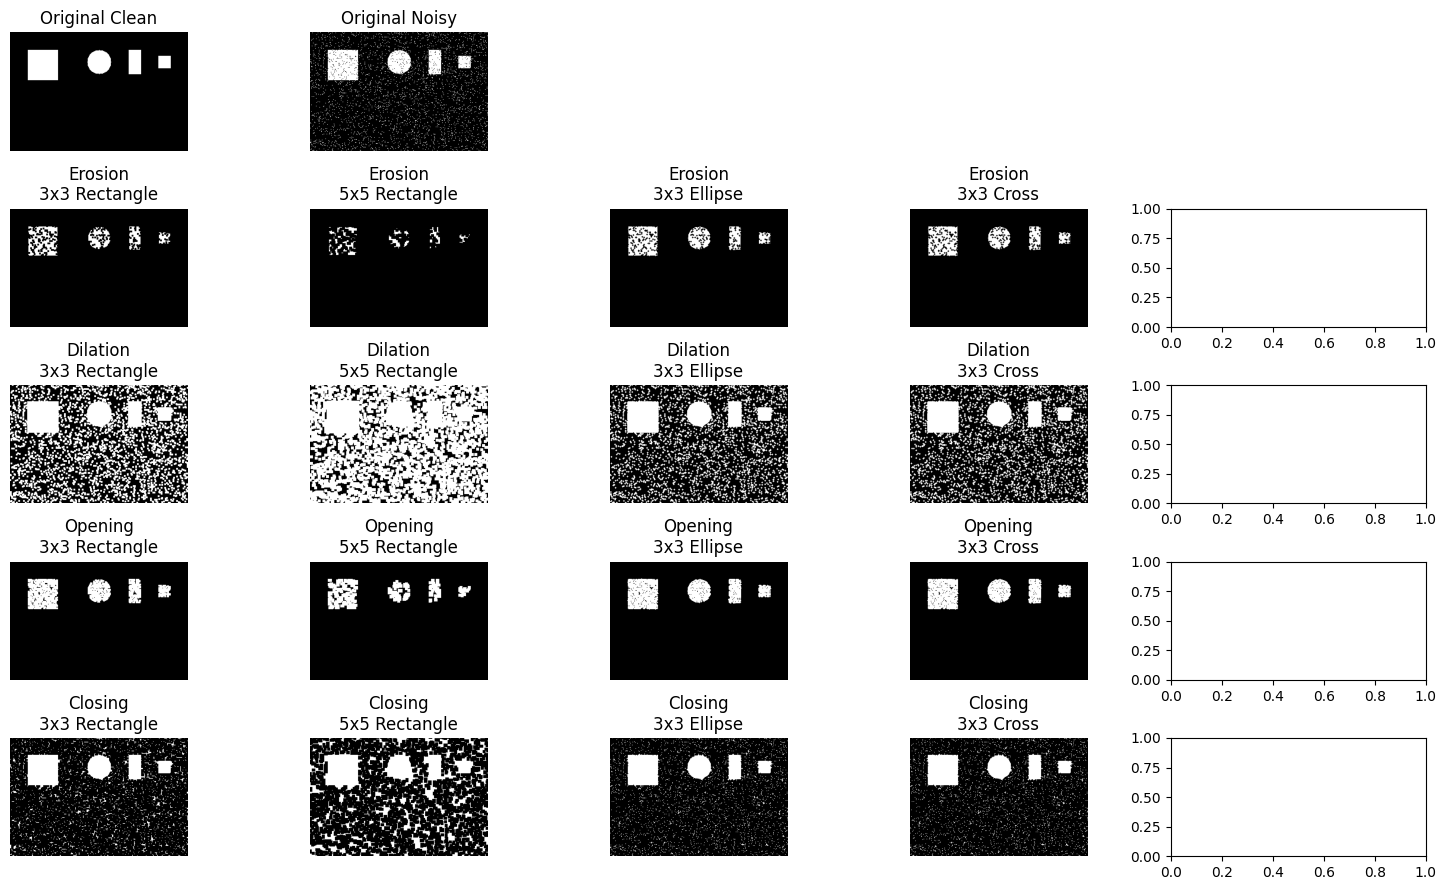

ANALYSIS OF MORPHOLOGICAL OPERATIONS:
1. Erosion:
   - Menghilangkan noise kecil
   - Mengecilkan objek

2. Dilation:
   - Mengisi lubang kecil
   - Membesarkan objek

3. Opening:
   - Menghilangkan noise tanpa merusak objek

4. Closing:
   - Mengisi lubang kecil pada objek


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def latihan_1():
    # Buat citra biner test pattern
    img = np.zeros((200, 300), dtype=np.uint8)

    # Tambahkan berbagai bentuk
    cv2.rectangle(img, (30, 30), (80, 80), 255, -1)
    cv2.circle(img, (150, 50), 20, 255, -1)
    cv2.rectangle(img, (200, 30), (220, 70), 255, -1)
    cv2.rectangle(img, (250, 40), (270, 60), 255, -1)

    # Tambahkan noise
    noise = np.random.random(img.shape) < 0.05
    img_noisy = img.copy()
    img_noisy[noise] = 255 - img_noisy[noise]

    # Structuring elements
    kernels = {
        '3x3 Rectangle': cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)),
        '5x5 Rectangle': cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)),
        '3x3 Ellipse': cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)),
        '3x3 Cross': cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
    }

    fig, axes = plt.subplots(5, 5, figsize=(15, 9))

    # Original images
    axes[0,0].imshow(img, cmap='gray')
    axes[0,0].set_title('Original Clean')
    axes[0,0].axis('off')

    axes[0,1].imshow(img_noisy, cmap='gray')
    axes[0,1].set_title('Original Noisy')
    axes[0,1].axis('off')

    for i in range(3):
        axes[0,i+2].axis('off')

    # Operasi morfologi
    operations = ['Erosion', 'Dilation', 'Opening', 'Closing']

    for row, op_name in enumerate(operations, 1):
        for col, (kernel_name, kernel) in enumerate(kernels.items()):

            if op_name == 'Erosion':
                result = cv2.erode(img_noisy, kernel, iterations=1)
            elif op_name == 'Dilation':
                result = cv2.dilate(img_noisy, kernel, iterations=1)
            elif op_name == 'Opening':
                result = cv2.morphologyEx(img_noisy, cv2.MORPH_OPEN, kernel)
            elif op_name == 'Closing':
                result = cv2.morphologyEx(img_noisy, cv2.MORPH_CLOSE, kernel)

            axes[row, col].imshow(result, cmap='gray')
            axes[row, col].set_title(f'{op_name}\n{kernel_name}')
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    # Analisis
    print("ANALYSIS OF MORPHOLOGICAL OPERATIONS:")
    print("=" * 50)
    print("1. Erosion:")
    print("   - Menghilangkan noise kecil")
    print("   - Mengecilkan objek")

    print("\n2. Dilation:")
    print("   - Mengisi lubang kecil")
    print("   - Membesarkan objek")

    print("\n3. Opening:")
    print("   - Menghilangkan noise tanpa merusak objek")

    print("\n4. Closing:")
    print("   - Mengisi lubang kecil pada objek")

# Jalankan
latihan_1()

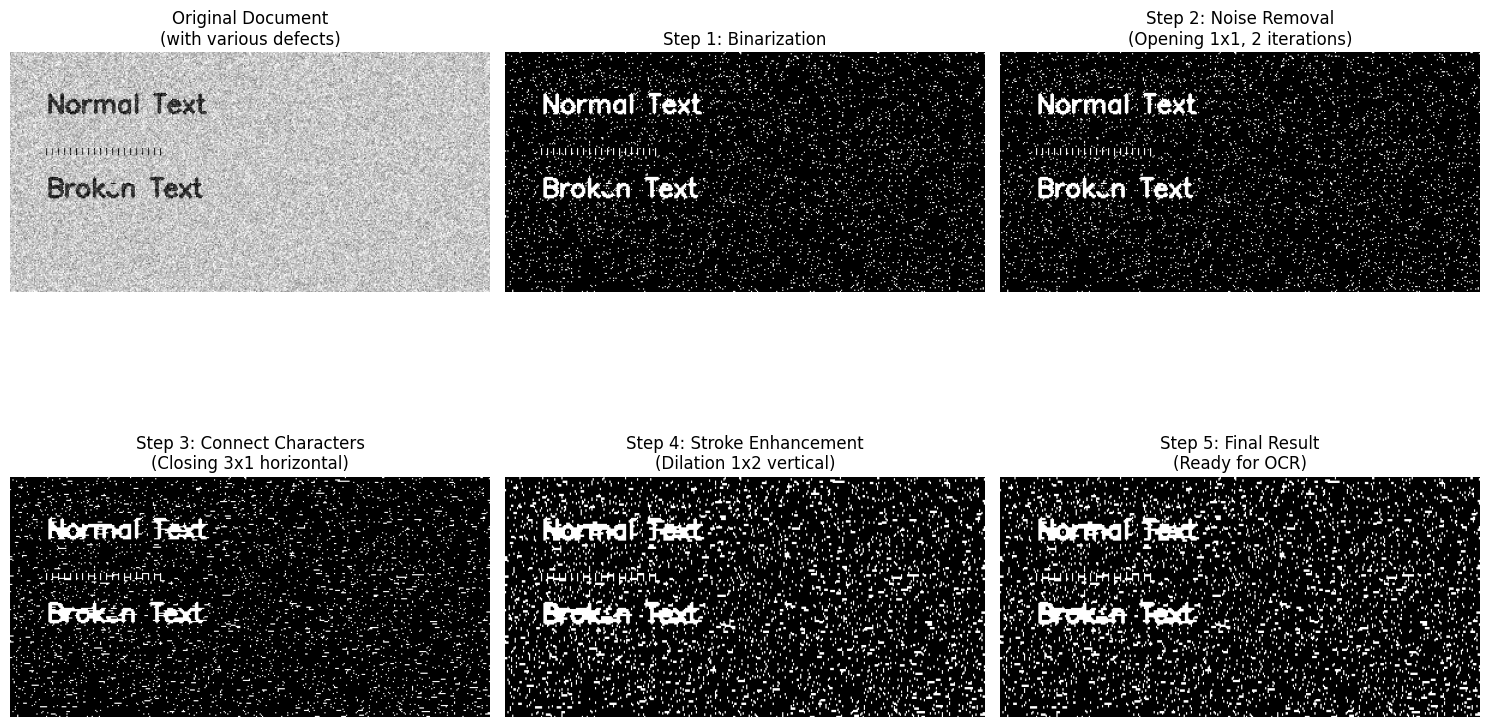

OCR PREPROCESSING QUALITY METRICS:
Connected Components Analysis:
  Original: 3167 components
  Processed: 2279 components
  Improvement: 28.0% reduction

Stroke Thickness Analysis:
  Original: 1.29 (avg pixels)
  Processed: 1.74 (avg pixels)
  Improvement: 34.9% increase

CONCLUSION:
Operasi morfologi dapat secara signifikan meningkatkan
kualitas citra teks untuk OCR dengan:
1. Menghilangkan noise
2. Menyambungkan karakter yang patah
3. Mempertebal stroke yang tipis


In [3]:
def latihan_2():
    # Simulasikan citra dokumen dengan berbagai masalah
    doc = np.ones((200, 400), dtype=np.uint8) * 200  # Background terang

    # Tambahkan teks dengan berbagai masalah
    font = cv2.FONT_HERSHEY_SIMPLEX

    # Teks normal
    cv2.putText(doc, 'Normal Text', (30, 50), font, 0.7, 50, 2)

    # Teks dengan noise (garis putus-putus)
    for i in range(0, 100, 5):
        cv2.line(doc, (30+i, 80), (30+i, 85), 50, 1)

    # Teks dengan lubang (karakter patah)
    cv2.putText(doc, 'Broken Text', (30, 120), font, 0.7, 50, 2)
    # Buat lubang di tengah karakter
    cv2.rectangle(doc, (80, 110), (90, 115), 200, -1)

    # Tambahkan background noise
    noise = np.random.normal(0, 30, doc.shape)
    doc = np.clip(doc.astype(float) + noise, 0, 255).astype(np.uint8)

    # Preprocessing pipeline untuk OCR
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Step 1: Original
    axes[0,0].imshow(doc, cmap='gray')
    axes[0,0].set_title('Original Document\n(with various defects)')
    axes[0,0].axis('off')

    # Step 2: Binarization
    _, binary = cv2.threshold(doc, 150, 255, cv2.THRESH_BINARY_INV)
    axes[0,1].imshow(binary, cmap='gray')
    axes[0,1].set_title('Step 1: Binarization')
    axes[0,1].axis('off')

    # Step 3: Noise removal dengan opening
    kernel_small = cv2.getStructuringElement(cv2.MORPH_RECT, (1,1))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_small, iterations=2)
    axes[0,2].imshow(cleaned, cmap='gray')
    axes[0,2].set_title('Step 2: Noise Removal\n(Opening 1x1, 2 iterations)')
    axes[0,2].axis('off')

    # Step 4: Connect broken characters dengan closing
    kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (3,1))
    connected = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel_horizontal)
    axes[1,0].imshow(connected, cmap='gray')
    axes[1,0].set_title('Step 3: Connect Characters\n(Closing 3x1 horizontal)')
    axes[1,0].axis('off')

    # Step 5: Enhance stroke thickness dengan dilation
    kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (1,2))
    enhanced = cv2.dilate(connected, kernel_vertical, iterations=1)
    axes[1,1].imshow(enhanced, cmap='gray')
    axes[1,1].set_title('Step 4: Stroke Enhancement\n(Dilation 1x2 vertical)')
    axes[1,1].axis('off')

    # Step 6: Final result
    final_result = enhanced
    axes[1,2].imshow(final_result, cmap='gray')
    axes[1,2].set_title('Step 5: Final Result\n(Ready for OCR)')
    axes[1,2].axis('off')

    plt.tight_layout()
    plt.show()

    # Quantitative evaluation
    def calculate_text_quality(original_binary, processed_binary):
        """Calculate simple text quality metrics"""
        # Connectivity analysis
        def count_connected_components(image):
            num_labels, labels = cv2.connectedComponents(image)
            return num_labels - 1  # Subtract background

        orig_components = count_connected_components(original_binary)
        proc_components = count_connected_components(processed_binary)

        # Stroke thickness (average)
        def average_stroke_thickness(image):
            # Simplified calculation using skeletonization
            skeleton = cv2.ximgproc.thinning(image)
            stroke_pixels = np.sum(image == 255)
            skeleton_pixels = np.sum(skeleton == 255)
            return stroke_pixels / skeleton_pixels if skeleton_pixels > 0 else 0

        orig_thickness = average_stroke_thickness(original_binary)
        proc_thickness = average_stroke_thickness(processed_binary)

        return {
            'connected_components': {
                'original': orig_components,
                'processed': proc_components,
                'improvement': (orig_components - proc_components) / orig_components * 100
            },
            'stroke_thickness': {
                'original': orig_thickness,
                'processed': proc_thickness,
                'improvement': (proc_thickness - orig_thickness) / orig_thickness * 100
            }
        }

    quality_metrics = calculate_text_quality(binary, final_result)

    print("OCR PREPROCESSING QUALITY METRICS:")
    print("=" * 50)
    print(f"Connected Components Analysis:")
    print(f"  Original: {quality_metrics['connected_components']['original']} components")
    print(f"  Processed: {quality_metrics['connected_components']['processed']} components")
    print(f"  Improvement: {quality_metrics['connected_components']['improvement']:.1f}% reduction")

    print(f"\nStroke Thickness Analysis:")
    print(f"  Original: {quality_metrics['stroke_thickness']['original']:.2f} (avg pixels)")
    print(f"  Processed: {quality_metrics['stroke_thickness']['processed']:.2f} (avg pixels)")
    print(f"  Improvement: {quality_metrics['stroke_thickness']['improvement']:.1f}% increase")

    print("\nCONCLUSION:")
    print("Operasi morfologi dapat secara signifikan meningkatkan")
    print("kualitas citra teks untuk OCR dengan:")
    print("1. Menghilangkan noise")
    print("2. Menyambungkan karakter yang patah")
    print("3. Mempertebal stroke yang tipis")

# Jalankan latihan 2
latihan_2()